# Strategies: which in-school choices pay off in job hunting
Alumni only: they are the ones with both campus records and job outcomes.
Salary premium (`sal_adj`) = first-job salary minus the median of grads with the same major and graduation year.

In [1]:
import os
import textwrap
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine
from scipy import stats
import statsmodels.formula.api as smf

# same data source as file.ipynb: Tiger Data when TIGER_URL is in .env, otherwise the local CSVs
load_dotenv()
tigerUrl = os.getenv("TIGER_URL")
engine = create_engine(tigerUrl.replace("postgres://", "postgresql+psycopg://", 1)) if tigerUrl else None

def load(table):
    if engine is None:
        return pd.read_csv(f"data/{table}.csv", na_values="Not Applicable")
    return pd.read_sql(f"SELECT * FROM {table} ORDER BY 1", engine)

stuCur = load("students_current")
stuExp = load("student_experience")
stuAlum = load("alumni")

# shared by the charts below
# sal_adj = first-job salary minus the median of grads with the same major and graduation year
sal = stuAlum["first_job_annual_salary_usd"]
stuAlum["sal_adj"] = sal - sal.groupby([stuAlum["major"], stuAlum["graduation_year"]]).transform("median")
# breadth = distinct experience types per person; people with no experience rows count as 0
ids = pd.concat([stuCur["campus_id"], stuAlum["campus_id"]])
breadth = stuExp.groupby("campus_id")["experience_type"].nunique().reindex(ids, fill_value=0)
blues = matplotlib.colors.LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#2a78d6", "#0d366b"])

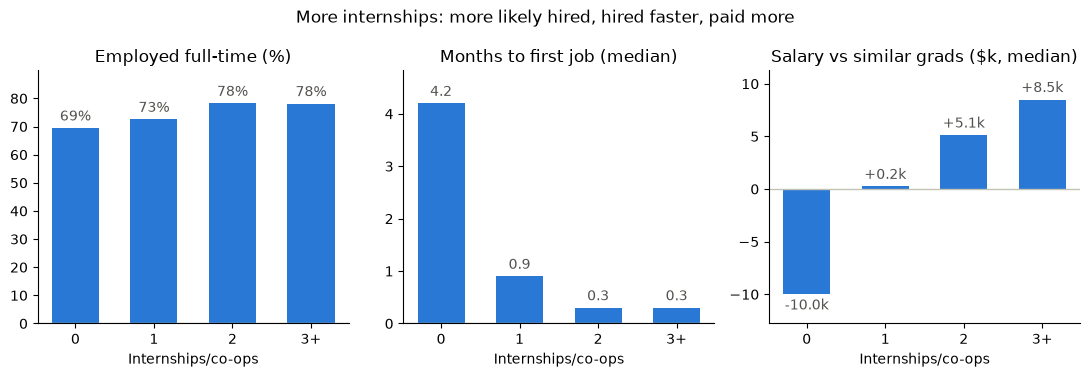

In [2]:
# Chart: job outcomes by number of internships/co-ops (alumni), small multiples
# employed = % "Employed Full-Time" among alumni who responded ("No Response" is unknown, not unemployed)
nIntern = stuAlum["internship_count"].clip(upper=3).map({0: "0", 1: "1", 2: "2", 3: "3+"})
alum = stuAlum.assign(nIntern=nIntern)
responded = alum[alum["first_destination"] != "No Response"]
panels = [
    ((responded["first_destination"] == "Employed Full-Time").groupby(responded["nIntern"]).mean() * 100,
     "Employed full-time (%)", "{:.0f}%"),
    (alum.groupby("nIntern")["months_to_first_job"].median(), "Months to first job (median)", "{:.1f}"),
    (alum.groupby("nIntern")["sal_adj"].median() / 1000, "Salary vs similar grads ($k, median)", "{:+.1f}k"),
]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
for ax, (s, name, fmt) in zip(axes, panels):
    ax.bar(s.index, s, color="#2a78d6", width=0.6)
    ax.bar_label(ax.containers[0], labels=[fmt.format(v) for v in s], padding=3, color="#52514e")
    ax.axhline(0, color="#c3c2b7", linewidth=1)
    ax.margins(y=0.15)
    ax.set(title=name, xlabel="Internships/co-ops")
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("More internships: more likely hired, hired faster, paid more")
fig.tight_layout()
plt.show()

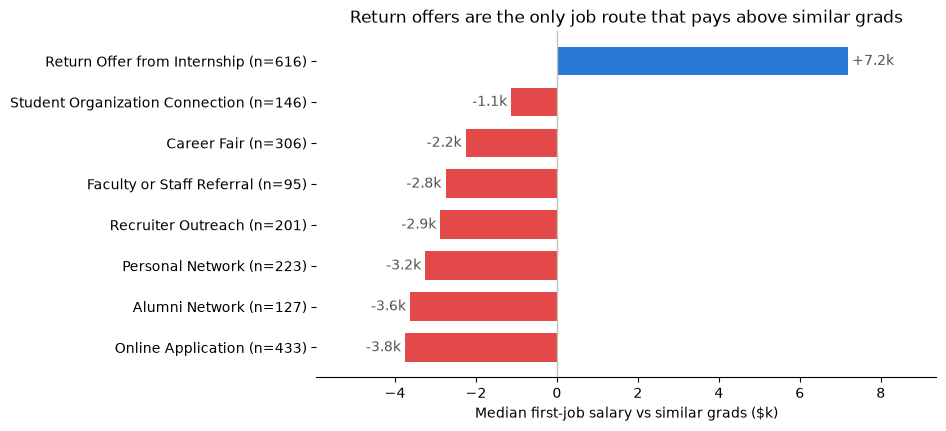

In [3]:
# Chart: median first-job salary premium by how the job was found (alumni), diverging bar
byChannel = (stuAlum.groupby("first_job_found_via")
             .agg(premium=("sal_adj", "median"), n=("sal_adj", "count"))
             .sort_values("premium"))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh([f"{c} (n={n})" for c, n in byChannel["n"].items()], byChannel["premium"] / 1000,
        color=["#2a78d6" if v > 0 else "#e34948" for v in byChannel["premium"]], height=0.7)
ax.bar_label(ax.containers[0], labels=[f"{v / 1000:+.1f}k" for v in byChannel["premium"]], padding=3, color="#52514e")
ax.axvline(0, color="#c3c2b7", linewidth=1)
ax.margins(x=0.2)
ax.set(xlabel="Median first-job salary vs similar grads ($k)",
       title="Return offers are the only job route that pays above similar grads")
ax.spines[["top", "right", "left"]].set_visible(False)
plt.show()

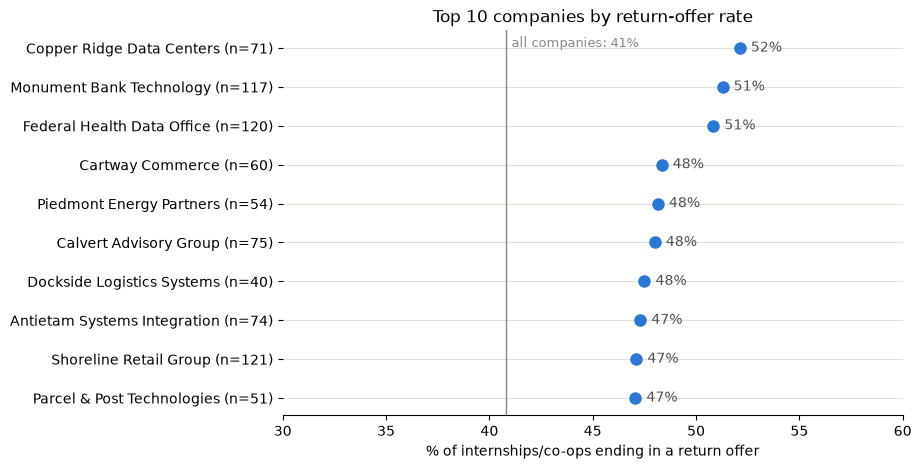

In [4]:
# Chart: top 10 companies by internship/co-op return-offer rate, dot plot (companies with >= 30 records)
# return offer = "Return offer accepted" or "Return offer declined"; "Converted to part-time role" doesn't count
work = stuExp[stuExp["experience_type"].isin(["Internship", "Co-op"])]
gotOffer = work["outcome"].isin(["Return offer accepted", "Return offer declined"])
offerRate = gotOffer.groupby(work["organization"]).agg(["mean", "size"])
top10Offer = offerRate[offerRate["size"] >= 30].nlargest(10, "mean")[::-1]   # reversed so #1 is on top
y = [f"{o} (n={n})" for o, n in top10Offer["size"].items()]
avg = gotOffer.mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.axvline(avg, color="#898781", linewidth=1)
ax.annotate(f"all companies: {avg:.0f}%", (avg, 1), xycoords=("data", "axes fraction"), xytext=(4, -4),
            textcoords="offset points", va="top", color="#898781", fontsize=9)
ax.scatter(top10Offer["mean"] * 100, y, color="#2a78d6", s=64, zorder=3)
for yi, v in zip(y, top10Offer["mean"]):
    ax.annotate(f"{v:.0%}", (v * 100, yi), xytext=(8, 0), textcoords="offset points", va="center", color="#52514e")
ax.set(xlim=(30, 60), xlabel="% of internships/co-ops ending in a return offer",
       title="Top 10 companies by return-offer rate")
ax.spines[["top", "right", "left"]].set_visible(False)
plt.show()

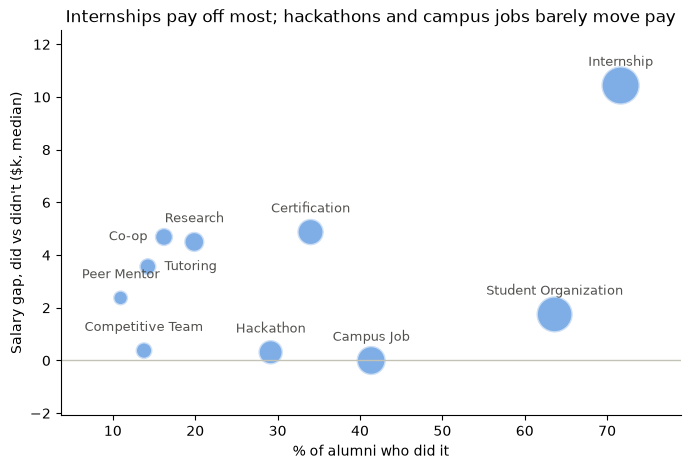

In [5]:
# Chart: which activity types pay off, bubble chart (alumni with a first-job salary)
# x = % of alumni who did the type; y = median premium of those who did minus those who didn't; size = alumni who did it
# blue = the gap is significant (Mann-Whitney, Bonferroni-corrected for 10 types, p < 0.05); gray = could be chance
withSalary = stuAlum[stuAlum["sal_adj"].notna()]
nTypes = stuExp["experience_type"].nunique()
rows = []
for t, grp in stuExp.groupby("experience_type"):
    did = withSalary["campus_id"].isin(grp["campus_id"])
    gap = withSalary.loc[did, "sal_adj"].median() - withSalary.loc[~did, "sal_adj"].median()
    p = min(1, stats.mannwhitneyu(withSalary.loc[did, "sal_adj"], withSalary.loc[~did, "sal_adj"]).pvalue * nTypes)
    rows.append((t, did.mean() * 100, gap / 1000, did.sum(), p))
payoff = pd.DataFrame(rows, columns=["type", "pct", "gap", "n", "p"])
significant = payoff["p"] < 0.05

fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(0, color="#c3c2b7", linewidth=1)
ax.scatter(payoff["pct"], payoff["gap"], s=payoff["n"] / 2, color=np.where(significant, "#2a78d6", "#c3c2b7"),
           alpha=0.7, edgecolor="white", linewidth=2)
ax.scatter([], [], s=80, color="#2a78d6", alpha=0.7, label="Significant gap (p < 0.05)")
ax.scatter([], [], s=80, color="#c3c2b7", alpha=0.7, label="Could be chance")
ax.legend(loc="lower right", frameon=False)
side = {"Co-op": "right", "Tutoring": "left"}   # these sit in a crowded corner, so their labels go beside the bubble
for _, r in payoff.iterrows():
    ha = side.get(r["type"], "center")
    ax.annotate(r["type"].replace("Undergraduate ", ""), (r["pct"], r["gap"]),
                xytext={"right": (-12, 0), "left": (12, 0), "center": (0, 12)}[ha], textcoords="offset points",
                ha=ha, va="bottom" if ha == "center" else "center", fontsize=9, color="#52514e")
ax.margins(x=0.12, y=0.2)
ax.set(xlabel="% of alumni who did it", ylabel="Salary gap, did vs didn't ($k, median)",
       title="Internships pay off most; hackathons and campus jobs barely move pay")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

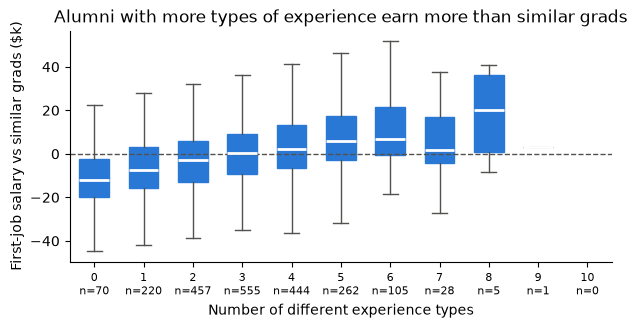

In [6]:
# Chart: box plot of alumni salary premium by number of experience types tried
# alumni only; salary minus the median of grads with the same major and graduation year (fair comparison across majors and years)
sal = stuAlum["first_job_annual_salary_usd"]
adj = (sal - sal.groupby([stuAlum["major"], stuAlum["graduation_year"]]).transform("median")) / 1000
grp = stuAlum["campus_id"].map(breadth)
data = [adj[(grp == k) & adj.notna()] for k in range(11)]
labels = [f"{k}\nn={len(d)}" for k, d in enumerate(data)]

fig, ax = plt.subplots(figsize=(7, 3))
ax.boxplot(data, tick_labels=labels, widths=0.6, showfliers=False, patch_artist=True,
           boxprops=dict(facecolor="#2a78d6", edgecolor="#2a78d6"), medianprops=dict(color="white", linewidth=2),
           whiskerprops=dict(color="#52514e"), capprops=dict(color="#52514e"))
ax.axhline(0, color="#52514e", linestyle="--", linewidth=1)
ax.tick_params(axis="x", labelsize=8)
ax.set(xlabel="Number of different experience types", ylabel="First-job salary vs similar grads ($k)",
       title="Alumni with more types of experience earn more than similar grads")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

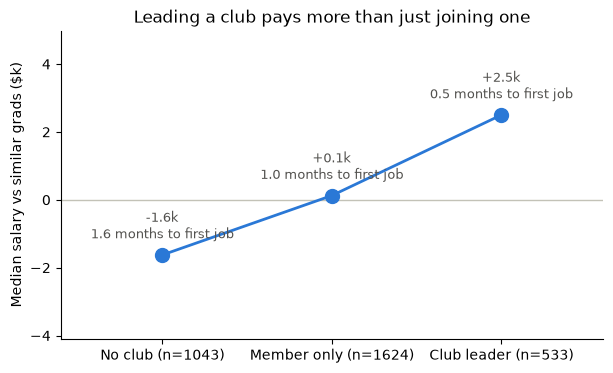

In [7]:
# Chart: salary premium and time to first job by club involvement (alumni), connected dot chart
# club leader = ever Officer/President/Lead in a club or competitive team; member only = joined one but never led
# the raw gaps are significant (Mann-Whitney p < 0.01), but they vanish once internships, GPA, breadth and
# certifications are held constant (regression table at the end): leaders simply intern more and have higher GPAs
clubRows = stuExp[stuExp["experience_type"].isin(["Student Organization", "Competitive Team"])]
leaderIds = clubRows.loc[clubRows["role_level"].isin(["Officer", "President", "Lead"]), "campus_id"]
role = np.select([stuAlum["campus_id"].isin(leaderIds), stuAlum["campus_id"].isin(clubRows["campus_id"])],
                 ["Club leader", "Member only"], "No club")
byRole = (stuAlum.assign(role=role).groupby("role")
          .agg(premium=("sal_adj", "median"), months=("months_to_first_job", "median"), n=("campus_id", "size"))
          .loc[["No club", "Member only", "Club leader"]])

fig, ax = plt.subplots(figsize=(7, 4))
ax.axhline(0, color="#c3c2b7", linewidth=1)
ax.plot([f"{r} (n={n})" for r, n in byRole["n"].items()], byRole["premium"] / 1000,
        color="#2a78d6", linewidth=2, marker="o", markersize=10)
for i, r in enumerate(byRole.itertuples()):
    ax.annotate(f"{r.premium / 1000:+.1f}k\n{r.months:.1f} months to first job", (i, r.premium / 1000),
                xytext=(0, 12), textcoords="offset points", ha="center", color="#52514e", fontsize=9)
ax.margins(x=0.3, y=0.6)
ax.set(ylabel="Median salary vs similar grads ($k)", title="Club leaders earn more, but it's their internships and GPA, not the title")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

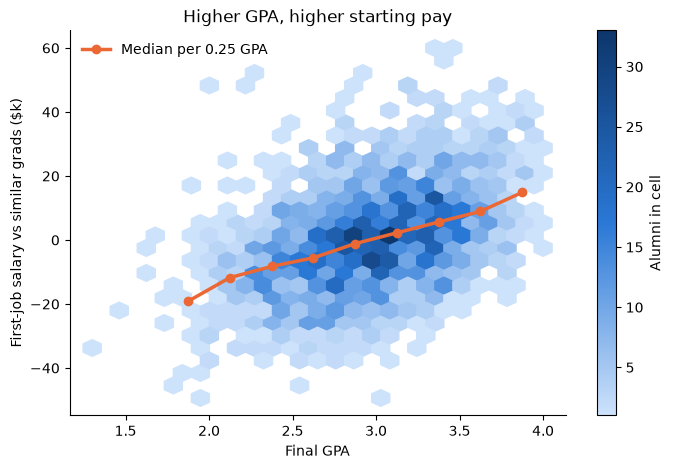

In [8]:
# Chart: final GPA vs first-job salary premium (alumni), hexbin density + median per 0.25 GPA (bands with >= 20 alumni)
# high-GPA grads also go to grad school more (15% vs 3%), so their full-time placement looks lower; they are not failing to get hired
withSalary = stuAlum[stuAlum["sal_adj"].notna()]
bands = pd.cut(withSalary["final_gpa"], np.arange(np.floor(withSalary["final_gpa"].min() * 4) / 4, 4.25, 0.25))
byBand = withSalary.groupby(bands, observed=True)["sal_adj"].agg(["median", "size"])
medianByBand = byBand.loc[byBand["size"] >= 20, "median"] / 1000   # thin low-GPA bands are just noise

fig, ax = plt.subplots(figsize=(8, 5))
hb = ax.hexbin(withSalary["final_gpa"], withSalary["sal_adj"] / 1000, gridsize=25, cmap=blues, mincnt=1)
ax.plot([b.mid for b in medianByBand.index], medianByBand, color="#eb6834", linewidth=2.5, marker="o",
        label="Median per 0.25 GPA")
fig.colorbar(hb, ax=ax, label="Alumni in cell")
ax.legend(loc="upper left", frameon=False)
ax.set(xlabel="Final GPA", ylabel="First-job salary vs similar grads ($k)", title="Higher GPA, higher starting pay")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

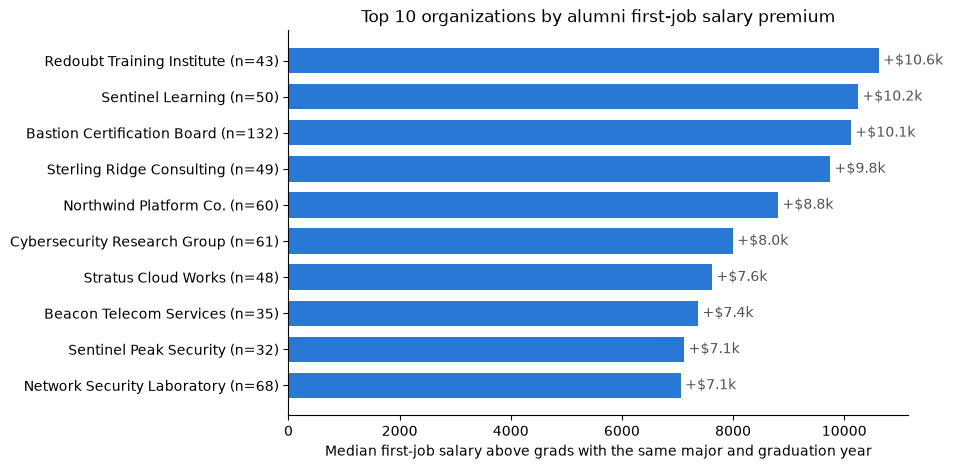

In [9]:
# Chart: top 10 organizations (n >= 30 alumni) by median first-job salary premium
# alumni only; one row per person per organization, so repeat entries don't double-count
# sal_adj = first-job salary minus the median of grads with the same major and graduation year
sal = stuAlum["first_job_annual_salary_usd"]
stuAlum["sal_adj"] = sal - sal.groupby([stuAlum["major"], stuAlum["graduation_year"]]).transform("median")
expAlu = stuExp[stuExp["campus_id"].isin(stuAlum["campus_id"])].drop_duplicates(["campus_id", "organization"])
m = expAlu.merge(stuAlum[["campus_id", "sal_adj"]], on="campus_id")

orgRank = m.groupby("organization").agg(
    n=("sal_adj", "count"),          # alumni with a first-job salary
    premium=("sal_adj", "median"),
)
top10 = orgRank[orgRank["n"] >= 30].nlargest(10, "premium")
plotData = top10[::-1]   # reversed so #1 is on top

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([f"{o} (n={n})" for o, n in plotData["n"].items()], plotData["premium"], color="#2a78d6", height=0.7)
ax.bar_label(ax.containers[0], labels=[f"+${v/1000:.1f}k" for v in plotData["premium"]], padding=3, color="#52514e")
ax.set(xlabel="Median first-job salary above grads with the same major and graduation year",
       title="Top 10 organizations by alumni first-job salary premium")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [ ]:
# Setup for the grade charts below: transcripts and the course catalog
# dfw = how many D, F or W grades each alum has (IP = in progress, left out)
stuTr = load("transcripts")
catalog = load("course_catalog")
graded = stuTr[stuTr["grade"] != "IP"]
isDfw = graded["grade"].isin(["D", "F", "W"])
stuAlum["dfw"] = stuAlum["campus_id"].map(graded[isDfw].groupby("campus_id").size()).fillna(0).astype(int)

In [ ]:
# Chart: years to degree and salary premium by number of D, F and W grades (alumni), small multiples
alum = stuAlum.assign(nDfw=stuAlum["dfw"].clip(upper=4).map({0: "0", 1: "1", 2: "2", 3: "3", 4: "4+"}))
panels = [
    (alum.groupby("nDfw")["time_to_degree_years"].mean(), "Years to degree (mean)", "{:.1f} yr"),
    (alum.groupby("nDfw")["sal_adj"].median() / 1000, "Salary vs similar grads ($k, median)", "{:+.1f}k"),
]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, (s, name, fmt) in zip(axes, panels):
    ax.bar(s.index, s, color="#2a78d6", width=0.6)
    ax.bar_label(ax.containers[0], labels=[fmt.format(v) for v in s], padding=3, color="#52514e")
    ax.axhline(0, color="#c3c2b7", linewidth=1)
    ax.margins(y=0.15)
    ax.set(title=name, xlabel="D, F and W grades")
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Each D, F or W slows the degree")
fig.tight_layout()
plt.show()

# each extra D/F/W, holding degree level and entry type fixed; and the pay gap once GPA is held fixed
years = smf.ols("time_to_degree_years ~ dfw + C(degree_level) + C(entry_type)", data=stuAlum).fit()
pay = smf.ols("sal_adj ~ dfw + final_gpa + internship_count + credential_count", data=stuAlum[stuAlum["sal_adj"].notna()]).fit()
print(f"+{years.params['dfw']:.2f} years per D/F/W (p = {years.pvalues['dfw']:.1g}); pay per D/F/W with GPA fixed: {pay.params['dfw']:+.0f} dollars (p = {pay.pvalues['dfw']:.2f})")

In [ ]:
# Chart: the 10 CS core courses with the most D, F and W grades, dot plot with 95% confidence intervals
csCore = catalog[(catalog["course_type"] == "Core") & catalog["required_for_majors"].str.contains("Computer Science", na=False)]
core = graded[graded["course_id"].isin(csCore["course_id"])]
rate = core["grade"].isin(["D", "F", "W"]).groupby(core["course_id"]).agg(["mean", "size"]).nlargest(10, "mean")[::-1]
ci = 1.96 * np.sqrt(rate["mean"] * (1 - rate["mean"]) / rate["size"]) * 100
titles = catalog.set_index("course_id")["course_title"]

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.errorbar(rate["mean"] * 100, range(len(rate)), xerr=ci, fmt="o", color="#2a78d6", ecolor="#9fc3ee", elinewidth=3)
ax.axvline(isDfw.mean() * 100, color="#c3c2b7", linestyle="--")
ax.text(isDfw.mean() * 100, len(rate) - 0.5, f" All courses: {isDfw.mean():.1%}", color="#52514e")
ax.set_yticks(range(len(rate)), [f"{c} {titles[c]}" for c in rate.index])
ax.set(title="The 10 CS core courses with the most D, F and W grades", xlabel="% of grades that were D, F or W")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

In [ ]:
# Chart: salary gap for taking each CS elective, holding GPA, internships, credentials and track fixed (OLS), with 95% CIs
# grey = doesn't pass a Bonferroni check over every elective tested (both majors)
electives = catalog[catalog["course_type"] == "Elective"].set_index("course_id")["course_title"]
takers = graded[graded["course_id"].isin(electives.index)].groupby("course_id")["campus_id"].agg(set)
withSalary = stuAlum[stuAlum["sal_adj"].notna()]
rows = []
for major, d in withSalary.groupby("major"):
    for cid, ids in takers.items():
        took = d["campus_id"].isin(ids).astype(int)
        if 50 <= took.sum() <= len(d) - 50:   # enough takers and non-takers to compare
            f = smf.ols("sal_adj ~ took + final_gpa + internship_count + credential_count + C(track)", data=d.assign(took=took)).fit()
            lo, hi = f.conf_int().loc["took"]
            rows.append((major, cid, f.params["took"], lo, hi, f.pvalues["took"]))
el = pd.DataFrame(rows, columns=["major", "course_id", "effect", "lo", "hi", "p"])
el["sig"] = el["p"] * len(el) < 0.05
cs = el[el["major"] == "Computer Science"].sort_values("effect")

fig, ax = plt.subplots(figsize=(8, 5.6))
for i, row in enumerate(cs.itertuples()):
    color = "#2a78d6" if row.sig else "#b4b2a9"
    ax.plot([row.lo / 1000, row.hi / 1000], [i, i], color=color, alpha=0.5, linewidth=3)
    ax.plot(row.effect / 1000, i, "o", color=color)
ax.axvline(0, color="#c3c2b7", linestyle="--")
ax.set_yticks(range(len(cs)), [f"{c} {electives[c]}" for c in cs["course_id"]])
ax.set(title="Security electives come with higher pay, even after GPA and internships", xlabel="Salary vs similar grads: took the elective vs didn't ($k)")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

In [ ]:
# Table: statistical checks behind each chart title, one factor at a time
# Spearman for ordered factors, Mann-Whitney for two-group gaps (salaries are skewed, so no t-tests)
withSalary = stuAlum[stuAlum["sal_adj"].notna()].assign(breadth=lambda d: d["campus_id"].map(breadth), role=lambda d: d["campus_id"].map(dict(zip(stuAlum["campus_id"], role))))
hiredAlum = stuAlum[stuAlum["months_to_first_job"].notna()]
responded = stuAlum[stuAlum["first_destination"] != "No Response"]
returnOffer = withSalary["first_job_found_via"] == "Return Offer from Internship"
mw = lambda x, y: stats.mannwhitneyu(x.dropna(), y.dropna()).pvalue
tests = [
    ("More internships -> more likely employed full-time", "Spearman",
     stats.spearmanr(responded["internship_count"], responded["first_destination"] == "Employed Full-Time")),
    ("More internships -> fewer months to first job", "Spearman",
     stats.spearmanr(hiredAlum["internship_count"], hiredAlum["months_to_first_job"])),
    ("More internships -> higher salary premium", "Spearman", stats.spearmanr(withSalary["internship_count"], withSalary["sal_adj"])),
    ("Return offers pay more than other routes", "Mann-Whitney", mw(withSalary["sal_adj"][returnOffer], withSalary["sal_adj"][~returnOffer])),
    ("More experience types -> higher premium", "Spearman", stats.spearmanr(withSalary["breadth"], withSalary["sal_adj"])),
    ("Club leaders earn more than members (raw)", "Mann-Whitney",
     mw(withSalary["sal_adj"][withSalary["role"] == "Club leader"], withSalary["sal_adj"][withSalary["role"] == "Member only"])),
    ("Higher GPA -> higher premium", "Spearman", stats.spearmanr(withSalary["final_gpa"], withSalary["sal_adj"])),
]
pd.DataFrame([(claim, test, getattr(r, "statistic", None), getattr(r, "pvalue", r)) for claim, test, r in tests],
             columns=["claim", "test", "rho", "p"]).assign(
    rho=lambda d: d["rho"].round(3), verdict=lambda d: np.where(d["p"] < 0.05, "supported", "not significant"),
    p=lambda d: d["p"].map(lambda p: f"{p:.1e}"))

In [ ]:
# Table: which factors still matter when considered together, OLS regressions (alumni with a first job)
# each coefficient = the change in the outcome for one more unit of that factor, holding the others constant
# club leadership drops out: its raw gap came from leaders also interning more and having higher GPAs
model = withSalary.assign(leader=(withSalary["role"] == "Club leader").astype(int), member=(withSalary["role"] == "Member only").astype(int))
formula = "internship_count + final_gpa + breadth + leader + member + credential_count"
fits = {"salary premium ($)": smf.ols(f"sal_adj ~ {formula}", data=model).fit(),
        "months to first job": smf.ols(f"months_to_first_job ~ {formula}", data=model).fit()}
pd.concat({name: pd.DataFrame({"coef": f.params.round(2), "p": f.pvalues.map(lambda p: f"{p:.1e}"),
                               "significant": f.pvalues < 0.05}).drop("Intercept")
           for name, f in fits.items()}, axis=1)